In [1]:
# =============================================
# 퍼널 분석 — 판매자 지각 분석
# 목적: 판매자 지각일별 최종 정시 도착률,
#       택배사 소요시간, 커버 가능 임계선 탐지
# 베이스: olist_order_item_level.csv
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df_all = pd.read_csv("../../../Funnel_Cohort_NG/data/olist_order_item_level.csv")

# 배송 완료 + 이상치 없는 데이터만
df = df_all[
    df_all['is_delivered'] == True
].copy()

# 날짜 컬럼 변환
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at', 
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# is_seller_late 생성
df['is_seller_late'] = (
    df['order_delivered_carrier_date'] > df['shipping_limit_date']
).astype(float)

# 판매자 지각일 계산
df['seller_delay_days'] = (
    df['order_delivered_carrier_date'] - df['shipping_limit_date']
).dt.days

print('전체 배송 완료:', len(df))
print('판매자 지각률:', round(df['is_seller_late'].mean()*100, 1), '%')
print('판매자 지각 건수:', int(df['is_seller_late'].sum()))
print()
print('컬럼 확인:')
print([c for c in df.columns if 'seller' in c or 'late' in c or 'delay' in c])

전체 배송 완료: 110197
판매자 지각률: 9.3 %
판매자 지각 건수: 10270

컬럼 확인:
['seller_id', 'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_state_kor', 'seller_region', 'seller_geo_lat', 'seller_geo_lng', 'seller_geo_city', 'seller_geo_state', 'seller_state_geo_mismatch', 'seller_customer_same_state', 'is_seller_late', 'seller_delay_days']


=== 판매자 지각일별 최종 정시 도착률 ===
seller_delay_bucket  total  ontime  ontime_rate
                 1일   1587    1292    81.411468
                 2일    582     434    74.570447
                 3일    486     367    75.514403
               4~5일    883     612    69.309173
               6~7일    644     380    59.006211
              8~14일    615     226    36.747967
               15일+    349      74    21.203438


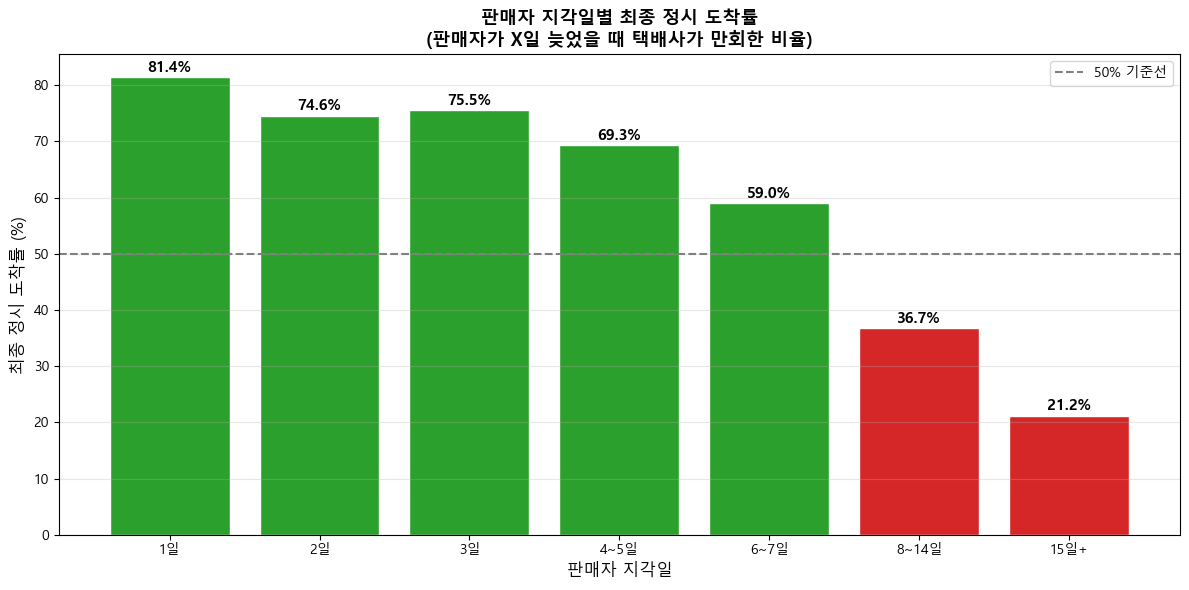

In [2]:
# =============================================
# 분석 1. 판매자 지각일별 최종 정시 도착률
# =============================================

# 판매자 지각일 구간 설정
df_late = df[df['is_seller_late'] == 1].copy()
df_late['seller_delay_bucket'] = pd.cut(
    df_late['seller_delay_days'],
    bins=[0, 1, 2, 3, 5, 7, 14, 999],
    labels=['1일', '2일', '3일', '4~5일', '6~7일', '8~14일', '15일+']
)

# 최종 정시 도착률 (is_late == False)
ontime_rate = df_late.groupby('seller_delay_bucket').agg(
    total=('is_late', 'count'),
    ontime=('is_late', lambda x: (x == False).sum())
).reset_index()
ontime_rate['ontime_rate'] = ontime_rate['ontime'] / ontime_rate['total'] * 100

print('=== 판매자 지각일별 최종 정시 도착률 ===')
print(ontime_rate.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(ontime_rate['seller_delay_bucket'], 
              ontime_rate['ontime_rate'],
              color=['#2ca02c' if x > 50 else '#d62728' for x in ontime_rate['ontime_rate']],
              edgecolor='white')
ax.axhline(50, color='gray', ls='--', lw=1.5, label='50% 기준선')
for bar, rate in zip(bars, ontime_rate['ontime_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('판매자 지각일별 최종 정시 도착률\n(판매자가 X일 늦었을 때 택배사가 만회한 비율)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('판매자 지각일', fontsize=12)
ax.set_ylabel('최종 정시 도착률 (%)', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== 지역별 판매자 지각 시 만회율 ===
seller_region  total  ontime  avg_seller_delay  ontime_rate
          북동부    226     120          3.827434    53.097345
           북부      4       3          1.250000    75.000000
          남동부   8420    6406          2.368009    76.080760
           남부   1475    1148          3.947797    77.830508
          중서부    144     118          2.736111    81.944444


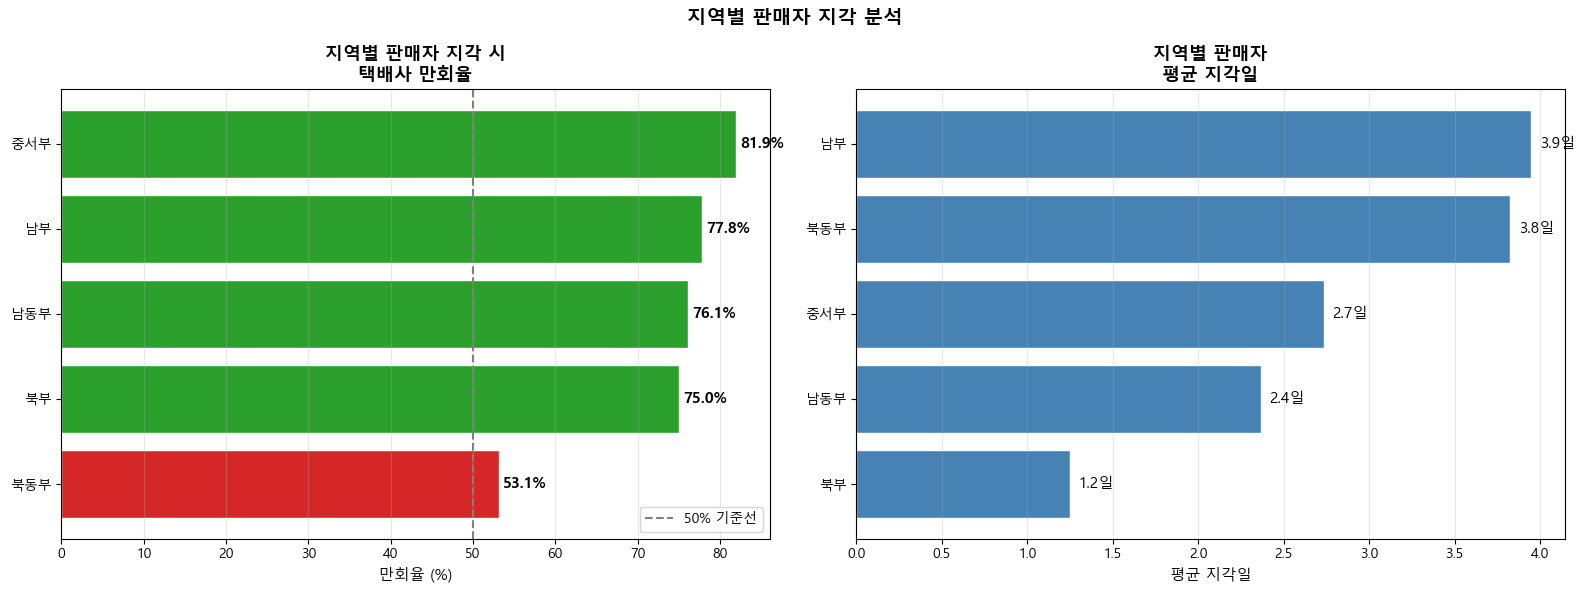

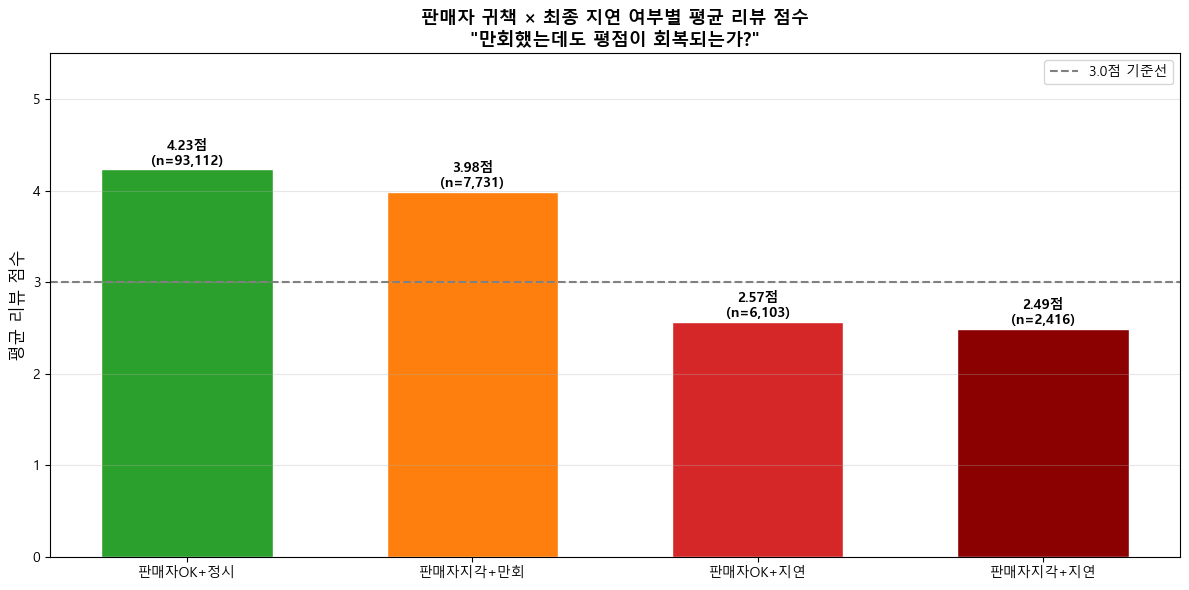

=== 케이스별 평균 리뷰 ===
    case  avg_review  count
판매자OK+정시    4.230445  93112
판매자지각+만회    3.983702   7731
판매자OK+지연    2.570867   6103
판매자지각+지연    2.493377   2416


In [3]:
# =============================================
# 분석 1-1. 지역별 판매자 지각 시 택배사 만회율
# =============================================

region_ontime = df_late.groupby('seller_region').agg(
    total=('is_late', 'count'),
    ontime=('is_late', lambda x: (x == False).sum()),
    avg_seller_delay=('seller_delay_days', 'mean')
).reset_index()
region_ontime['ontime_rate'] = region_ontime['ontime'] / region_ontime['total'] * 100

print('=== 지역별 판매자 지각 시 만회율 ===')
print(region_ontime.sort_values('ontime_rate').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 지역별 만회율
colors = ['#d62728' if x < 60 else '#ff7f0e' if x < 70 else '#2ca02c' 
          for x in region_ontime.sort_values('ontime_rate')['ontime_rate']]
bars = axes[0].barh(
    region_ontime.sort_values('ontime_rate')['seller_region'],
    region_ontime.sort_values('ontime_rate')['ontime_rate'],
    color=colors, edgecolor='white'
)
axes[0].axvline(50, color='gray', ls='--', lw=1.5, label='50% 기준선')
for bar, rate in zip(bars, region_ontime.sort_values('ontime_rate')['ontime_rate']):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                f'{rate:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[0].set_title('지역별 판매자 지각 시\n택배사 만회율', fontsize=13, fontweight='bold')
axes[0].set_xlabel('만회율 (%)', fontsize=11)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# 오른쪽: 지역별 판매자 평균 지각일
axes[1].barh(
    region_ontime.sort_values('avg_seller_delay')['seller_region'],
    region_ontime.sort_values('avg_seller_delay')['avg_seller_delay'],
    color='steelblue', edgecolor='white'
)
for i, (_, row) in enumerate(region_ontime.sort_values('avg_seller_delay').iterrows()):
    axes[1].text(row['avg_seller_delay']+0.05, i,
                f'{row["avg_seller_delay"]:.1f}일', va='center', fontsize=11)
axes[1].set_title('지역별 판매자\n평균 지각일', fontsize=13, fontweight='bold')
axes[1].set_xlabel('평균 지각일', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('지역별 판매자 지각 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# 분석 1-2. 만회했을 때 평점 vs 완벽 정시 평점
# =============================================

# 4가지 케이스
df['case'] = '기타'
df.loc[(df['is_seller_late']==0) & (df['is_late']==False), 'case'] = '판매자OK+정시'
df.loc[(df['is_seller_late']==0) & (df['is_late']==True), 'case'] = '판매자OK+지연'
df.loc[(df['is_seller_late']==1) & (df['is_late']==False), 'case'] = '판매자지각+만회'
df.loc[(df['is_seller_late']==1) & (df['is_late']==True), 'case'] = '판매자지각+지연'

case_review = df[df['case'] != '기타'].groupby('case')['review_score_mean'].agg(
    ['mean','count']
).reset_index()
case_review.columns = ['case', 'avg_review', 'count']

order = ['판매자OK+정시', '판매자지각+만회', '판매자OK+지연', '판매자지각+지연']
case_review['case'] = pd.Categorical(case_review['case'], categories=order, ordered=True)
case_review = case_review.sort_values('case')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#8b0000']
bars = ax.bar(case_review['case'], case_review['avg_review'],
              color=colors, edgecolor='white', width=0.6)
ax.axhline(3.0, color='gray', ls='--', lw=1.5, label='3.0점 기준선')
for bar, (_, row) in zip(bars, case_review.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{row["avg_review"]:.2f}점\n(n={int(row["count"]):,})',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('판매자 귀책 × 최종 지연 여부별 평균 리뷰 점수\n"만회했는데도 평점이 회복되는가?"',
             fontsize=13, fontweight='bold')
ax.set_ylabel('평균 리뷰 점수', fontsize=12)
ax.set_ylim(0, 5.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('=== 케이스별 평균 리뷰 ===')
print(case_review.to_string(index=False))

=== 판매자 지각일별 택배사 소요시간 ===
판매자 정상 그룹 택배사 중앙값: 7.1일

seller_delay_bucket  median_delivery  mean_delivery  count
                 1일         7.108900       9.769221   1587
                 2일         7.072448       9.310367    582
                 3일         7.314554       9.358083    486
               4~5일         7.110556       9.715940    883
               6~7일         7.777778      10.682255    644
              8~14일         7.637465      10.395885    615
               15일+         7.774537       9.895953    349


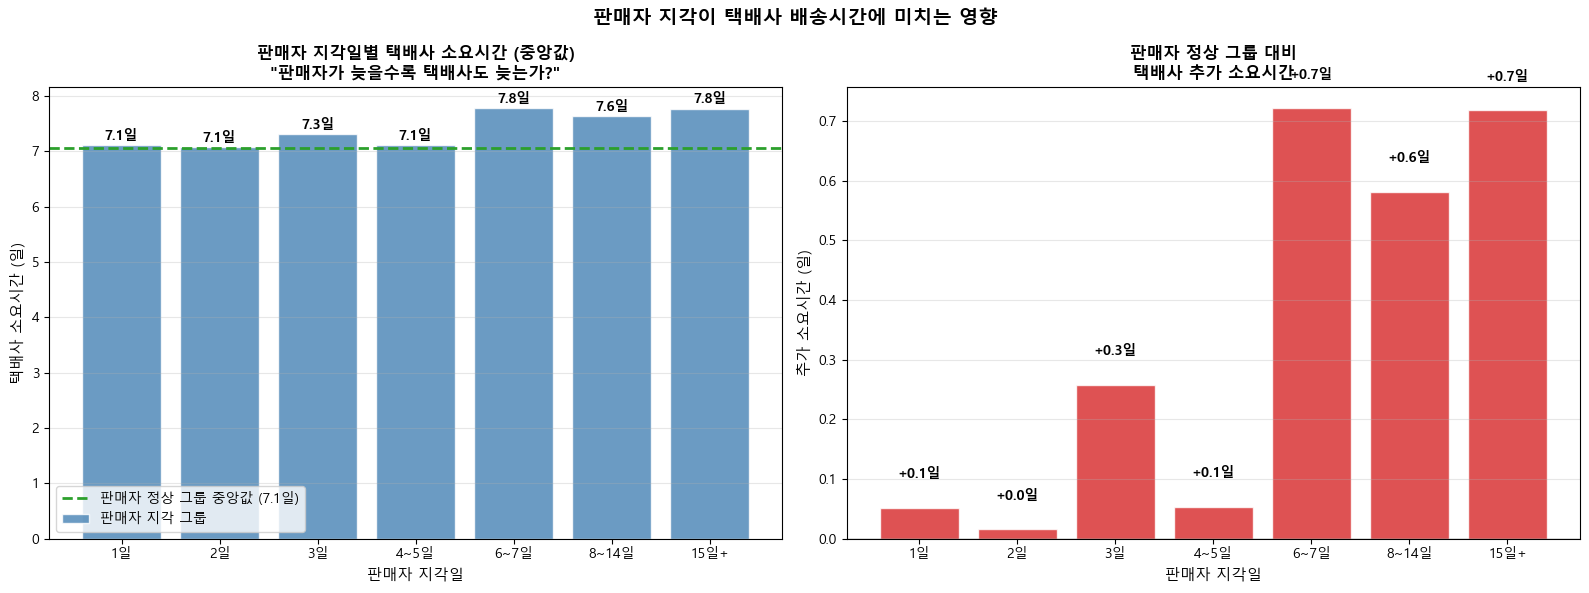

In [4]:
# =============================================
# 분석 2. 판매자 지각일별 택배사 소요시간
# 판매자가 늦을수록 택배사도 늦는가?
# =============================================

# 택배사 소요시간 컬럼 생성
df['t_delivery_d'] = (
    df['order_delivered_customer_date'] - df['order_delivered_carrier_date']
).dt.total_seconds() / 86400

df_late['t_delivery_d'] = (
    df_late['order_delivered_customer_date'] - df_late['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# 정상 판매자 그룹 택배사 소요시간
normal_delivery = df[df['is_seller_late']==0]['t_delivery_d'].median()

# 판매자 지각일별 택배사 소요시간
delivery_by_delay = df_late.groupby('seller_delay_bucket')['t_delivery_d'].agg(
    ['median','mean','count']
).reset_index()
delivery_by_delay.columns = ['seller_delay_bucket','median_delivery','mean_delivery','count']

print('=== 판매자 지각일별 택배사 소요시간 ===')
print(f'판매자 정상 그룹 택배사 중앙값: {normal_delivery:.1f}일')
print()
print(delivery_by_delay.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 택배사 소요시간 비교
axes[0].bar(delivery_by_delay['seller_delay_bucket'],
            delivery_by_delay['median_delivery'],
            color='steelblue', edgecolor='white', alpha=0.8, label='판매자 지각 그룹')
axes[0].axhline(normal_delivery, color='#2ca02c', ls='--', lw=2,
                label=f'판매자 정상 그룹 중앙값 ({normal_delivery:.1f}일)')
for i, row in delivery_by_delay.iterrows():
    axes[0].text(i, row['median_delivery']+0.1,
                f'{row["median_delivery"]:.1f}일',
                ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('판매자 지각일별 택배사 소요시간 (중앙값)\n"판매자가 늦을수록 택배사도 늦는가?"',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('판매자 지각일', fontsize=11)
axes[0].set_ylabel('택배사 소요시간 (일)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 정상 대비 추가 소요시간
delivery_by_delay['extra_days'] = delivery_by_delay['median_delivery'] - normal_delivery
colors = ['#d62728' if x > 0 else '#2ca02c' for x in delivery_by_delay['extra_days']]
axes[1].bar(delivery_by_delay['seller_delay_bucket'],
            delivery_by_delay['extra_days'],
            color=colors, edgecolor='white', alpha=0.8)
axes[1].axhline(0, color='gray', ls='-', lw=1)
for i, row in delivery_by_delay.iterrows():
    axes[1].text(i, row['extra_days']+0.05 if row['extra_days'] >= 0 else row['extra_days']-0.3,
                f'+{row["extra_days"]:.1f}일' if row['extra_days'] >= 0 else f'{row["extra_days"]:.1f}일',
                ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('판매자 정상 그룹 대비\n택배사 추가 소요시간',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('판매자 지각일', fontsize=11)
axes[1].set_ylabel('추가 소요시간 (일)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('판매자 지각이 택배사 배송시간에 미치는 영향', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== 배송 타이밍별 평균 리뷰 점수 ===
 timing  avg_review  count
 7일+ 빠름    4.225917  86858
4~7일 빠름    4.132201  10658
2~3일 빠름    4.090021   3327
  1일 빠름    3.987117   1436
     정시    3.679185    932
1~3일 지연    2.869377   1156
4~7일 지연    2.089810   1943
 7일+ 지연    1.697903   3052


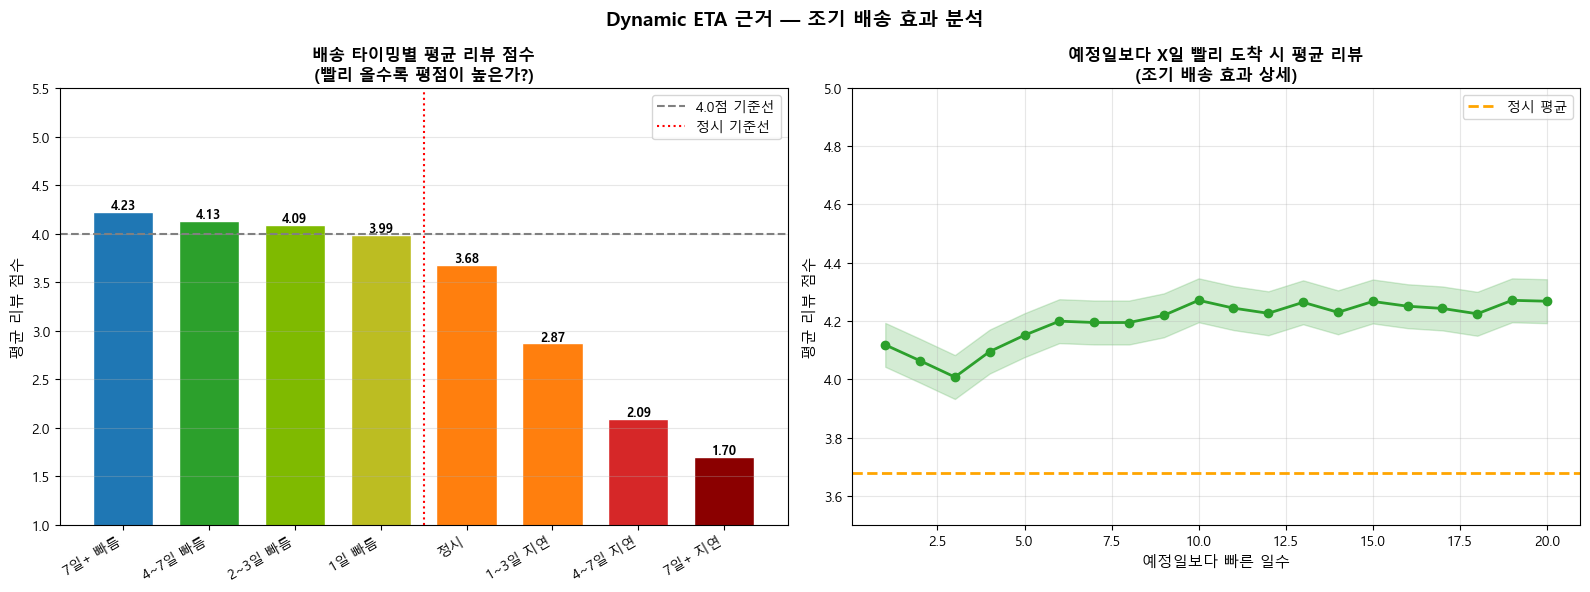

In [5]:
# =============================================
# 분석 3. 조기 배송 효과 — Dynamic ETA 근거
# 예정일보다 일찍 도착할수록 평점이 높은가?
# =============================================

# delay_days 음수 = 조기 배송
df_early = df[df['is_late'].notna()].copy()
df_early['delay_days'] = (
    df_early['order_delivered_customer_date'] - 
    df_early['order_estimated_delivery_date']
).dt.days

# 조기/정시/지연 구간 설정
df_early['delivery_timing'] = pd.cut(
    df_early['delay_days'],
    bins=[-999, -7, -3, -1, 0, 1, 3, 7, 999],
    labels=['7일+ 빠름', '4~7일 빠름', '2~3일 빠름', '1일 빠름', 
            '정시', '1~3일 지연', '4~7일 지연', '7일+ 지연']
)

timing_review = df_early.groupby('delivery_timing')['review_score_mean'].agg(
    ['mean', 'count']
).reset_index()
timing_review.columns = ['timing', 'avg_review', 'count']

print('=== 배송 타이밍별 평균 리뷰 점수 ===')
print(timing_review.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 타이밍별 평균 리뷰
colors = ['#1f77b4','#2ca02c','#7fba00','#bcbd22',
          '#ff7f0e','#ff7f0e','#d62728','#8b0000']
bars = axes[0].bar(range(len(timing_review)), timing_review['avg_review'],
                   color=colors, edgecolor='white', width=0.7)
axes[0].axhline(4.0, color='gray', ls='--', lw=1.5, label='4.0점 기준선')
axes[0].axvline(3.5, color='red', ls=':', lw=1.5, label='정시 기준선')
for bar, (_, row) in zip(bars, timing_review.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f'{row["avg_review"]:.2f}',
                ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(timing_review)))
axes[0].set_xticklabels(timing_review['timing'], rotation=30, ha='right', fontsize=10)
axes[0].set_title('배송 타이밍별 평균 리뷰 점수\n(빨리 올수록 평점이 높은가?)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[0].set_ylim(1, 5.5)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 조기 배송 구간별 상세 (음수 구간만)
df_before = df_early[df_early['delay_days'] < 0].copy()
df_before['early_day'] = df_before['delay_days'].abs()
daily_early = df_before.groupby('early_day')['review_score_mean'].agg(
    ['mean','count']
)
daily_early = daily_early[daily_early['count'] >= 30].loc[:20]

axes[1].plot(daily_early.index, daily_early['mean'], 
             'o-', color='#2ca02c', lw=2, ms=6)
axes[1].axhline(timing_review[timing_review['timing']=='정시']['avg_review'].values[0],
                color='orange', ls='--', lw=2, label='정시 평균')
axes[1].fill_between(daily_early.index, 
                     daily_early['mean'] - daily_early['mean'].std(),
                     daily_early['mean'] + daily_early['mean'].std(),
                     alpha=0.2, color='#2ca02c')
axes[1].set_title('예정일보다 X일 빨리 도착 시 평균 리뷰\n(조기 배송 효과 상세)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('예정일보다 빠른 일수', fontsize=11)
axes[1].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(3.5, 5)

plt.suptitle('Dynamic ETA 근거 — 조기 배송 효과 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

정시 도착 건수: 1,450건
정시 평균 리뷰: 3.99점

=== 예정일 길이별 정시 도착 평점 ===
window  avg_review  count
  ~10일    4.334347    329
11~15일    3.918079    177
16~20일    3.985484    310
21~25일    3.853693    352
26~30일    3.988024    167
  30일+    3.445545    101


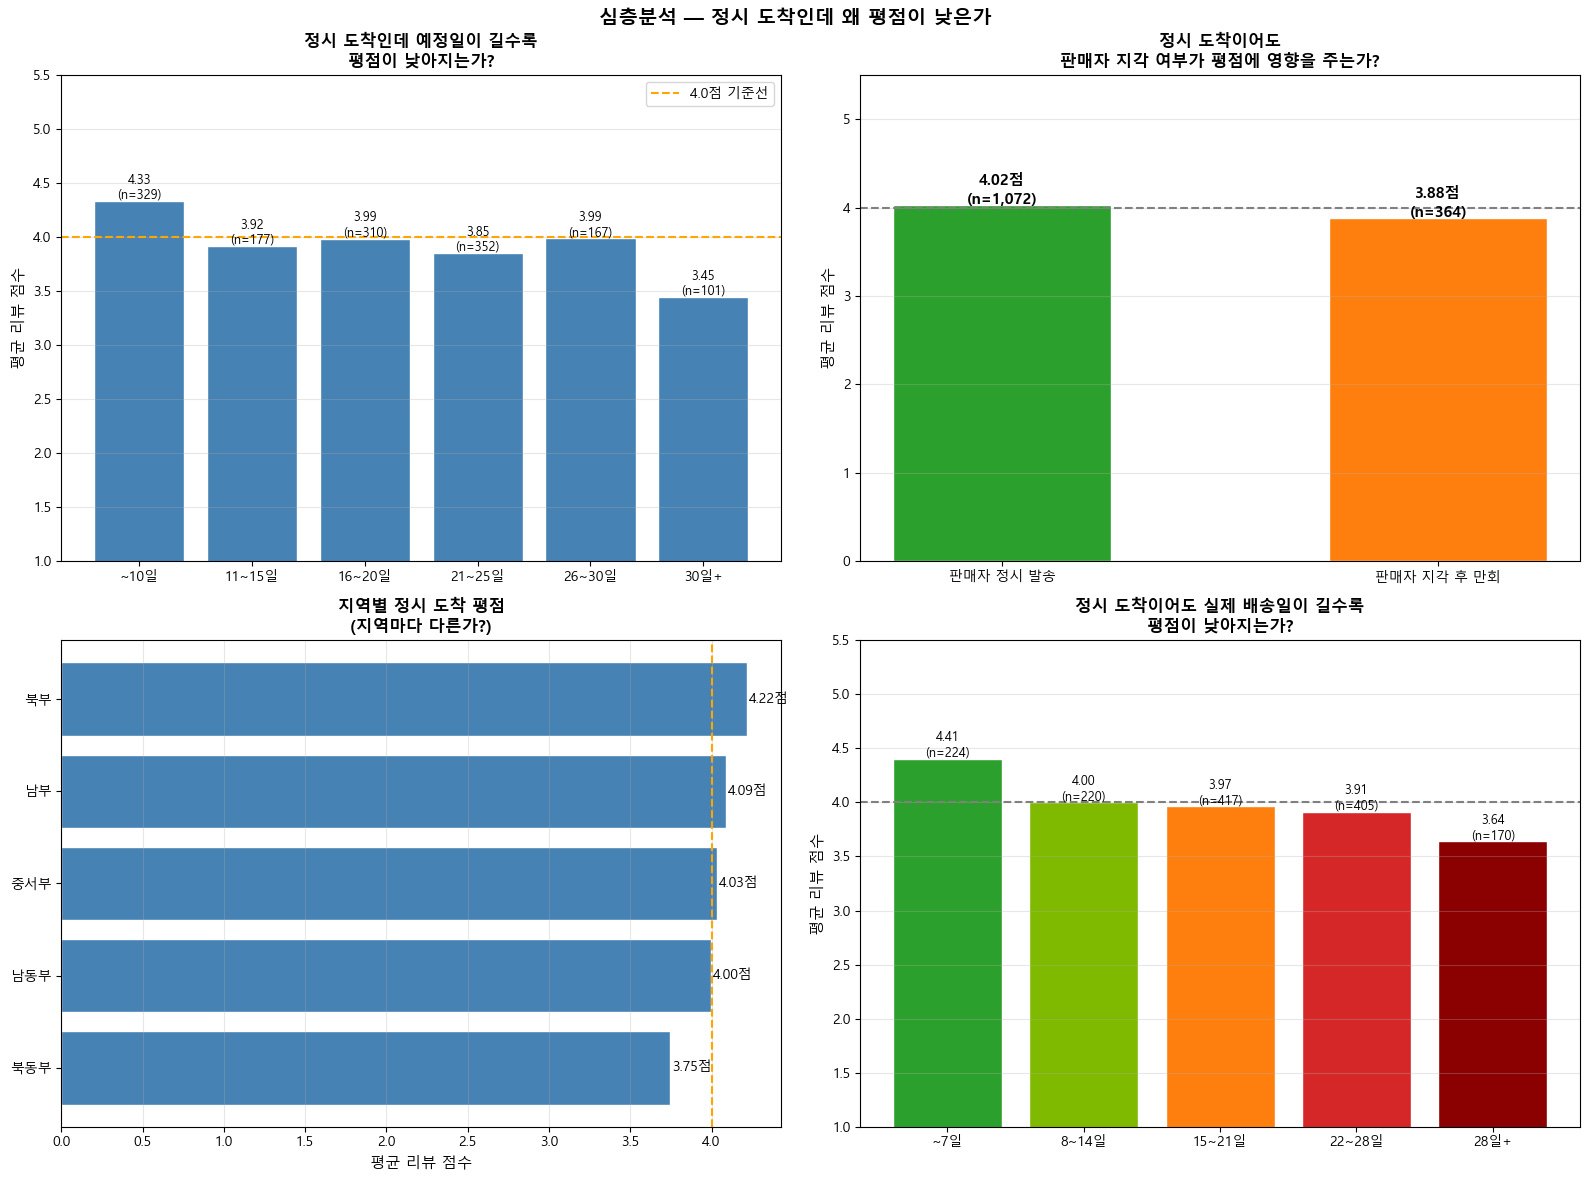

In [6]:
# =============================================
# 심층분석 — 정시 도착인데 왜 평점이 낮은가
# 정시(delay_days=0) 그룹 분해 분석
# =============================================

# 정시 그룹만
df_ontime = df_early[df_early['delay_days'] == 0].copy()

print(f'정시 도착 건수: {len(df_ontime):,}건')
print(f'정시 평균 리뷰: {df_ontime["review_score_mean"].mean():.2f}점')
print()

# 1. 예정일 길이별 평점 비교
# 예정일이 길었던 주문 vs 짧았던 주문
df_ontime['estimated_window'] = (
    df_ontime['order_estimated_delivery_date'] - 
    df_ontime['order_purchase_timestamp']
).dt.days

df_ontime['window_bucket'] = pd.cut(
    df_ontime['estimated_window'],
    bins=[0, 10, 15, 20, 25, 30, 999],
    labels=['~10일', '11~15일', '16~20일', '21~25일', '26~30일', '30일+']
)

window_review = df_ontime.groupby('window_bucket')['review_score_mean'].agg(
    ['mean','count']
).reset_index()
window_review.columns = ['window', 'avg_review', 'count']

print('=== 예정일 길이별 정시 도착 평점 ===')
print(window_review.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 좌상: 예정일 길이별 평점
bars = axes[0][0].bar(window_review['window'], window_review['avg_review'],
                      color='steelblue', edgecolor='white')
axes[0][0].axhline(4.0, color='orange', ls='--', lw=1.5, label='4.0점 기준선')
for bar, (_, row) in zip(bars, window_review.iterrows()):
    axes[0][0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                   f'{row["avg_review"]:.2f}\n(n={int(row["count"]):,})',
                   ha='center', fontsize=9)
axes[0][0].set_title('정시 도착인데 예정일이 길수록\n평점이 낮아지는가?',
                     fontsize=12, fontweight='bold')
axes[0][0].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[0][0].set_ylim(1, 5.5)
axes[0][0].legend()
axes[0][0].grid(axis='y', alpha=0.3)

# 우상: 판매자 지각 여부별 정시 도착 평점
seller_ontime = df_ontime.groupby('is_seller_late')['review_score_mean'].agg(
    ['mean','count']
).reset_index()
seller_ontime['group'] = seller_ontime['is_seller_late'].map(
    {0.0:'판매자 정시 발송', 1.0:'판매자 지각 후 만회'}
)
colors = ['#2ca02c', '#ff7f0e']
bars2 = axes[0][1].bar(seller_ontime['group'], seller_ontime['mean'],
                       color=colors, edgecolor='white', width=0.5)
for bar, (_, row) in zip(bars2, seller_ontime.iterrows()):
    axes[0][1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                   f'{row["mean"]:.2f}점\n(n={int(row["count"]):,})',
                   ha='center', fontsize=11, fontweight='bold')
axes[0][1].set_title('정시 도착이어도\n판매자 지각 여부가 평점에 영향을 주는가?',
                     fontsize=12, fontweight='bold')
axes[0][1].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[0][1].set_ylim(0, 5.5)
axes[0][1].axhline(4.0, color='gray', ls='--', lw=1.5)
axes[0][1].grid(axis='y', alpha=0.3)

# 좌하: 지역별 정시 도착 평점
region_ontime_review = df_ontime.groupby('customer_region')['review_score_mean'].agg(
    ['mean','count']
).reset_index()
region_ontime_review.columns = ['region','avg_review','count']
region_ontime_review = region_ontime_review.sort_values('avg_review')

bars3 = axes[1][0].barh(region_ontime_review['region'], 
                         region_ontime_review['avg_review'],
                         color='steelblue', edgecolor='white')
axes[1][0].axvline(4.0, color='orange', ls='--', lw=1.5)
for bar, (_, row) in zip(bars3, region_ontime_review.iterrows()):
    axes[1][0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                   f'{row["avg_review"]:.2f}점',
                   va='center', fontsize=10)
axes[1][0].set_title('지역별 정시 도착 평점\n(지역마다 다른가?)',
                     fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('평균 리뷰 점수', fontsize=11)
axes[1][0].grid(axis='x', alpha=0.3)

# 우하: 실제 배송일 길이별 정시 도착 평점
df_ontime['actual_days'] = (
    df_ontime['order_delivered_customer_date'] - 
    df_ontime['order_purchase_timestamp']
).dt.days

df_ontime['actual_bucket'] = pd.cut(
    df_ontime['actual_days'],
    bins=[0, 7, 14, 21, 28, 999],
    labels=['~7일', '8~14일', '15~21일', '22~28일', '28일+']
)
actual_review = df_ontime.groupby('actual_bucket')['review_score_mean'].agg(
    ['mean','count']
).reset_index()
actual_review.columns = ['actual','avg_review','count']

bars4 = axes[1][1].bar(actual_review['actual'], actual_review['avg_review'],
                        color=['#2ca02c','#7fba00','#ff7f0e','#d62728','#8b0000'],
                        edgecolor='white')
axes[1][1].axhline(4.0, color='gray', ls='--', lw=1.5)
for bar, (_, row) in zip(bars4, actual_review.iterrows()):
    axes[1][1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                   f'{row["avg_review"]:.2f}\n(n={int(row["count"]):,})',
                   ha='center', fontsize=9)
axes[1][1].set_title('정시 도착이어도 실제 배송일이 길수록\n평점이 낮아지는가?',
                     fontsize=12, fontweight='bold')
axes[1][1].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1][1].set_ylim(1, 5.5)
axes[1][1].grid(axis='y', alpha=0.3)

plt.suptitle('심층분석 — 정시 도착인데 왜 평점이 낮은가', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== 지역별 예정일 vs 실제 배송일 비교 ===
customer_region  avg_estimated  avg_actual  buffer_days  avg_review late_rate  count
            남동부          21.32       10.22        11.10        4.11  0.072486  75732
             남부          26.17       13.51        12.66        4.10  0.068392  15880
            북동부          30.36       19.44        10.92        3.91  0.141568  10087
             북부          37.31       22.15        15.15        3.97  0.098612   2018
            중서부          26.37       14.49        11.88        4.04  0.079012   6480


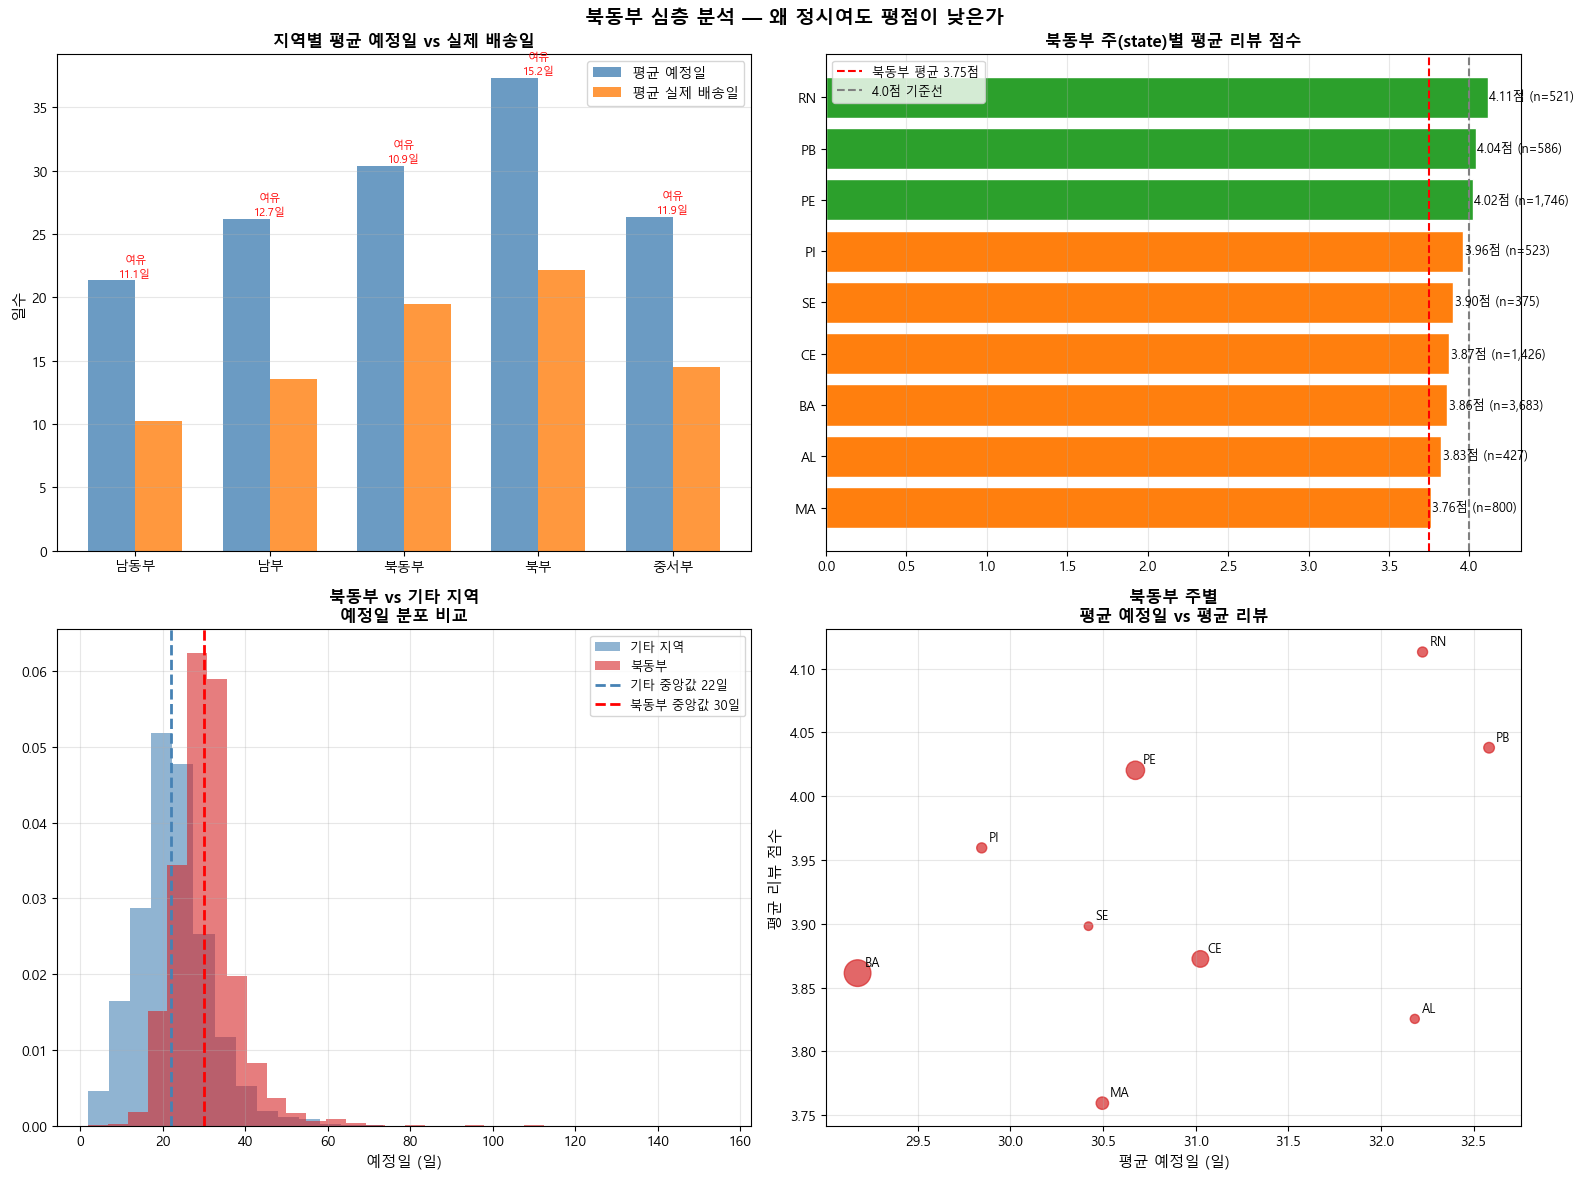

In [7]:
# =============================================
# 심층분석 2 — 북동부 집중 분석
# 왜 정시 도착해도 평점이 낮은가
# =============================================

# 북동부 vs 나머지 비교
df['is_northeast'] = df['customer_region'] == '북동부'

# 1. 예정일 길이 비교
df['estimated_window'] = (
    df['order_estimated_delivery_date'] - 
    df['order_purchase_timestamp']
).dt.days

df['actual_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_purchase_timestamp']
).dt.days

region_summary = df.groupby('customer_region').agg(
    avg_estimated=('estimated_window', 'mean'),
    avg_actual=('actual_days', 'mean'),
    median_estimated=('estimated_window', 'median'),
    median_actual=('actual_days', 'median'),
    avg_review=('review_score_mean', 'mean'),
    late_rate=('is_late', 'mean'),
    count=('order_id', 'count')
).reset_index()
region_summary['buffer_days'] = region_summary['avg_estimated'] - region_summary['avg_actual']

print('=== 지역별 예정일 vs 실제 배송일 비교 ===')
print(region_summary[['customer_region','avg_estimated','avg_actual',
                       'buffer_days','avg_review','late_rate','count']].round(2).to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 좌상: 예정일 vs 실제 배송일 비교
x = range(len(region_summary))
width = 0.35
axes[0][0].bar([i-width/2 for i in x], region_summary['avg_estimated'],
               width=width, color='steelblue', alpha=0.8, label='평균 예정일')
axes[0][0].bar([i+width/2 for i in x], region_summary['avg_actual'],
               width=width, color='#ff7f0e', alpha=0.8, label='평균 실제 배송일')
axes[0][0].set_xticks(x)
axes[0][0].set_xticklabels(region_summary['customer_region'])
axes[0][0].set_title('지역별 평균 예정일 vs 실제 배송일', fontsize=12, fontweight='bold')
axes[0][0].set_ylabel('일수', fontsize=11)
axes[0][0].legend()
axes[0][0].grid(axis='y', alpha=0.3)
for i, row in region_summary.iterrows():
    axes[0][0].text(i, max(row['avg_estimated'], row['avg_actual'])+0.3,
                   f'여유\n{row["buffer_days"]:.1f}일',
                   ha='center', fontsize=8, color='red')

# 우상: 북동부 주(state)별 상세
df_ne = df[df['customer_region'] == '북동부']
ne_state = df_ne.groupby('customer_state').agg(
    avg_estimated=('estimated_window', 'mean'),
    avg_actual=('actual_days', 'mean'),
    avg_review=('review_score_mean', 'mean'),
    late_rate=('is_late', 'mean'),
    count=('order_id', 'count')
).reset_index().sort_values('avg_review')

axes[0][1].barh(ne_state['customer_state'], ne_state['avg_review'],
                color=['#d62728' if x < 3.5 else '#ff7f0e' if x < 4.0 else '#2ca02c' 
                       for x in ne_state['avg_review']],
                edgecolor='white')
axes[0][1].axvline(3.75, color='red', ls='--', lw=1.5, label='북동부 평균 3.75점')
axes[0][1].axvline(4.0, color='gray', ls='--', lw=1.5, label='4.0점 기준선')
for i, row in ne_state.iterrows():
    axes[0][1].text(row['avg_review']+0.01, 
                   list(ne_state['customer_state']).index(row['customer_state']),
                   f'{row["avg_review"]:.2f}점 (n={int(row["count"]):,})',
                   va='center', fontsize=9)
axes[0][1].set_title('북동부 주(state)별 평균 리뷰 점수', fontsize=12, fontweight='bold')
axes[0][1].legend(fontsize=9)
axes[0][1].grid(axis='x', alpha=0.3)

# 좌하: 북동부 예정일 분포 vs 전체
axes[1][0].hist(df[df['customer_region']!='북동부']['estimated_window'].dropna(),
                bins=30, alpha=0.6, color='steelblue', label='기타 지역', density=True)
axes[1][0].hist(df_ne['estimated_window'].dropna(),
                bins=30, alpha=0.6, color='#d62728', label='북동부', density=True)
axes[1][0].axvline(df[df['customer_region']!='북동부']['estimated_window'].median(),
                   color='steelblue', ls='--', lw=2,
                   label=f'기타 중앙값 {df[df["customer_region"]!="북동부"]["estimated_window"].median():.0f}일')
axes[1][0].axvline(df_ne['estimated_window'].median(),
                   color='red', ls='--', lw=2,
                   label=f'북동부 중앙값 {df_ne["estimated_window"].median():.0f}일')
axes[1][0].set_title('북동부 vs 기타 지역\n예정일 분포 비교', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('예정일 (일)', fontsize=11)
axes[1][0].legend(fontsize=9)
axes[1][0].grid(alpha=0.3)

# 우하: 북동부 지연율 vs 평균 예정일 산점도
axes[1][1].scatter(ne_state['avg_estimated'], ne_state['avg_review'],
                   s=ne_state['count']/10, alpha=0.7, color='#d62728')
for _, row in ne_state.iterrows():
    axes[1][1].annotate(row['customer_state'],
                       (row['avg_estimated'], row['avg_review']),
                       textcoords='offset points', xytext=(5,5), fontsize=9)
axes[1][1].set_title('북동부 주별\n평균 예정일 vs 평균 리뷰', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('평균 예정일 (일)', fontsize=11)
axes[1][1].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1][1].grid(alpha=0.3)

plt.suptitle('북동부 심층 분석 — 왜 정시여도 평점이 낮은가', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# delay_days df에 추가
df['delay_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_estimated_delivery_date']
).dt.days

df_ma = df[df['customer_state'] == 'MA'].copy()
df_ne_others = df[(df['customer_region'] == '북동부') & (df['customer_state'] != 'MA')].copy()

print('delay_days 추가 완료')
print(f'MA 건수: {len(df_ma):,}')

delay_days 추가 완료
MA 건수: 800


MA 주 건수: 800건
MA 평균 예정일: 30.5일
MA 평균 실제 배송일: 21.2일
MA 지연율: 20.4%
MA 평균 리뷰: 3.76점

북동부 기타 평균 예정일: 30.4일
북동부 기타 지연율: 13.6%
북동부 기타 평균 리뷰: 3.92점


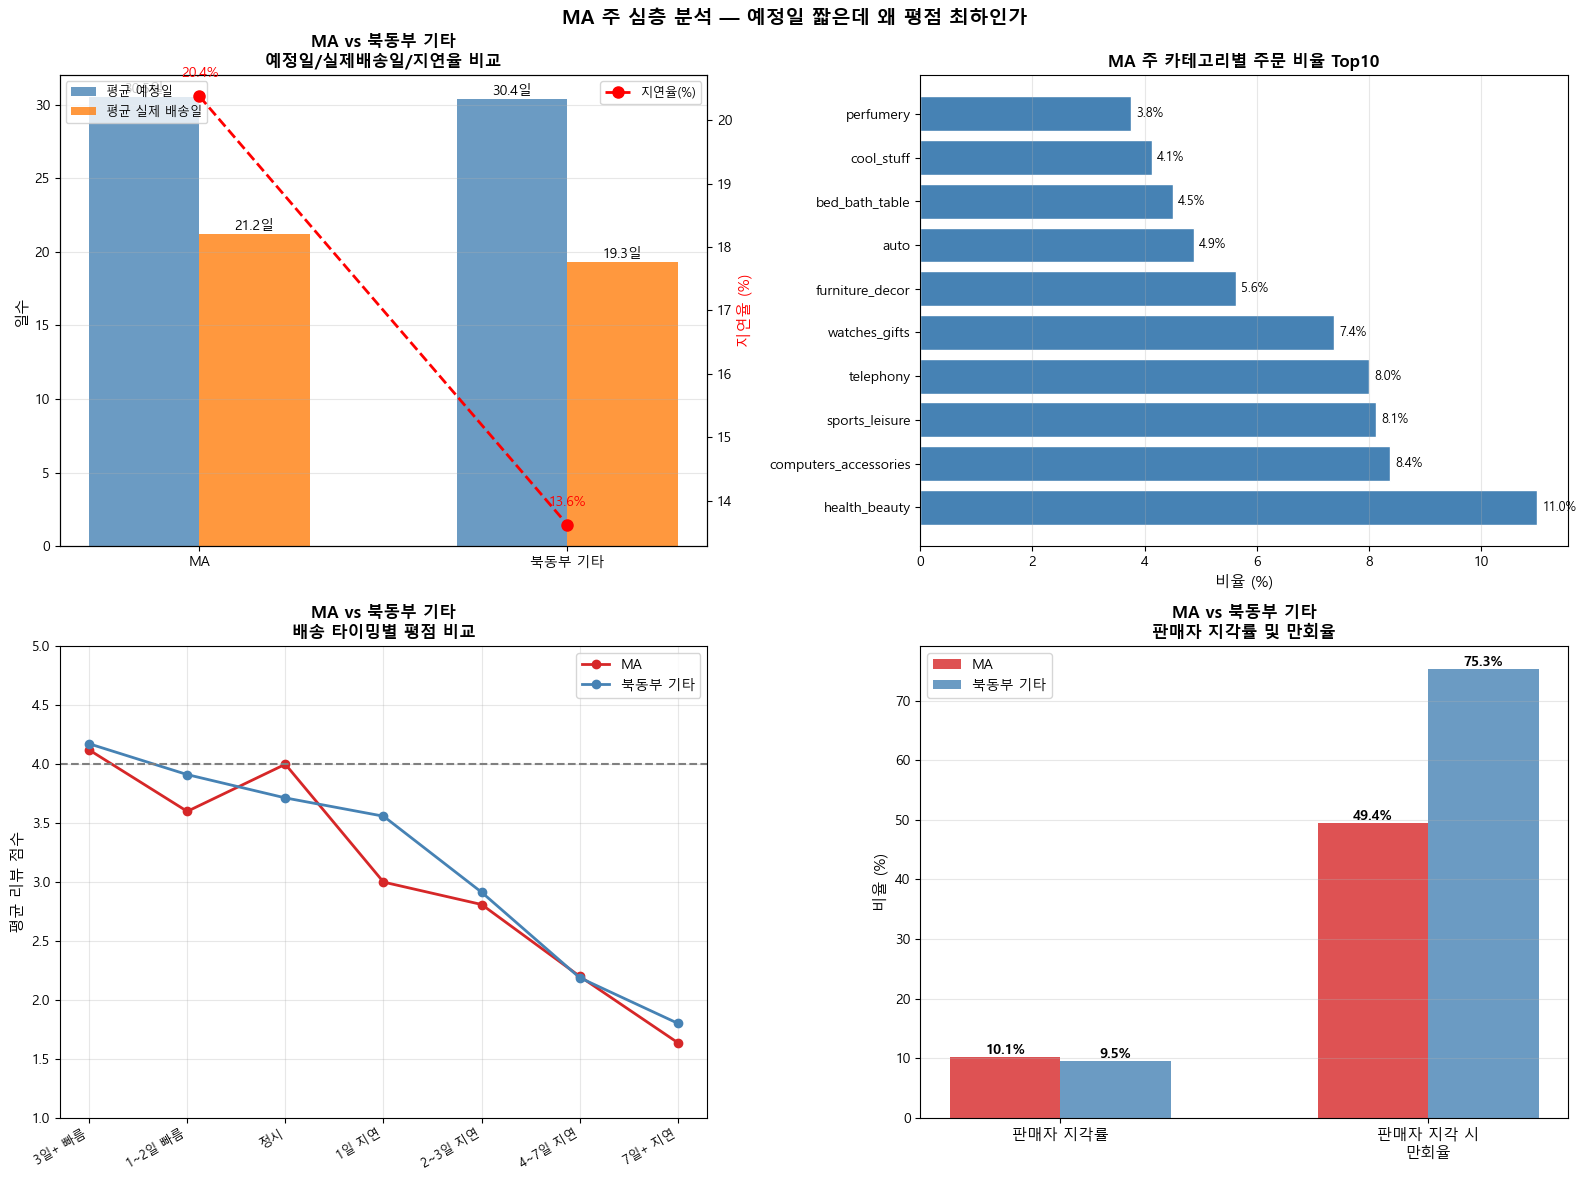

In [10]:
# =============================================
# 심층분석 3 — MA 주 집중 분석
# 예정일 짧은데 왜 평점이 최하인가
# =============================================

df_ma = df[df['customer_state'] == 'MA'].copy()
df_others = df[df['customer_region'] == '북동부'][df['customer_region'] == '북동부'].copy()
df_ne_others = df[(df['customer_region'] == '북동부') & (df['customer_state'] != 'MA')].copy()

print(f'MA 주 건수: {len(df_ma):,}건')
print(f'MA 평균 예정일: {df_ma["estimated_window"].mean():.1f}일')
print(f'MA 평균 실제 배송일: {df_ma["actual_days"].mean():.1f}일')
print(f'MA 지연율: {df_ma["is_late"].mean()*100:.1f}%')
print(f'MA 평균 리뷰: {df_ma["review_score_mean"].mean():.2f}점')
print()
print(f'북동부 기타 평균 예정일: {df_ne_others["estimated_window"].mean():.1f}일')
print(f'북동부 기타 지연율: {df_ne_others["is_late"].mean()*100:.1f}%')
print(f'북동부 기타 평균 리뷰: {df_ne_others["review_score_mean"].mean():.2f}점')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 좌상: MA vs 북동부 기타 예정일 vs 실제 배송일 vs 지연율
categories = ['MA', '북동부 기타']
est_days = [df_ma['estimated_window'].mean(), df_ne_others['estimated_window'].mean()]
act_days = [df_ma['actual_days'].mean(), df_ne_others['actual_days'].mean()]
late_rates = [df_ma['is_late'].mean()*100, df_ne_others['is_late'].mean()*100]

x = range(2)
width = 0.3
axes[0][0].bar([i-width/2 for i in x], est_days, width=width,
               color='steelblue', alpha=0.8, label='평균 예정일')
axes[0][0].bar([i+width/2 for i in x], act_days, width=width,
               color='#ff7f0e', alpha=0.8, label='평균 실제 배송일')
ax2 = axes[0][0].twinx()
ax2.plot(x, late_rates, 'o--', color='red', lw=2, ms=8, label='지연율(%)')
ax2.set_ylabel('지연율 (%)', fontsize=11, color='red')
for i, (e, a, l) in enumerate(zip(est_days, act_days, late_rates)):
    axes[0][0].text(i-width/2, e+0.3, f'{e:.1f}일', ha='center', fontsize=10)
    axes[0][0].text(i+width/2, a+0.3, f'{a:.1f}일', ha='center', fontsize=10)
    ax2.text(i, l+0.3, f'{l:.1f}%', ha='center', fontsize=10, color='red')
axes[0][0].set_xticks(x)
axes[0][0].set_xticklabels(categories)
axes[0][0].set_title('MA vs 북동부 기타\n예정일/실제배송일/지연율 비교', fontsize=12, fontweight='bold')
axes[0][0].set_ylabel('일수', fontsize=11)
axes[0][0].legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
axes[0][0].grid(axis='y', alpha=0.3)

# 우상: MA 카테고리별 주문 비율 Top10
ma_cat = df_ma.groupby('product_category_name_english').size().reset_index(name='count')
ma_cat = ma_cat.sort_values('count', ascending=False).head(10)
ma_cat['pct'] = ma_cat['count'] / len(df_ma) * 100

axes[0][1].barh(ma_cat['product_category_name_english'],
                ma_cat['pct'], color='steelblue', edgecolor='white')
for i, row in ma_cat.iterrows():
    axes[0][1].text(row['pct']+0.1,
                   list(ma_cat['product_category_name_english']).index(row['product_category_name_english']),
                   f'{row["pct"]:.1f}%', va='center', fontsize=9)
axes[0][1].set_title('MA 주 카테고리별 주문 비율 Top10', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('비율 (%)', fontsize=11)
axes[0][1].grid(axis='x', alpha=0.3)

# 좌하: MA 지연일별 평점 vs 북동부 기타
ma_timing = df_ma.groupby(pd.cut(df_ma['delay_days'],
    bins=[-999,-3,-1,0,1,3,7,999],
    labels=['3일+ 빠름','1~2일 빠름','정시','1일 지연','2~3일 지연','4~7일 지연','7일+ 지연']
))['review_score_mean'].mean().reset_index()
ma_timing.columns = ['timing','avg_review']

ne_timing = df_ne_others.groupby(pd.cut(df_ne_others['delay_days'],
    bins=[-999,-3,-1,0,1,3,7,999],
    labels=['3일+ 빠름','1~2일 빠름','정시','1일 지연','2~3일 지연','4~7일 지연','7일+ 지연']
))['review_score_mean'].mean().reset_index()
ne_timing.columns = ['timing','avg_review']

x = range(len(ma_timing))
axes[1][0].plot(x, ma_timing['avg_review'], 'o-', color='#d62728', lw=2, ms=6, label='MA')
axes[1][0].plot(x, ne_timing['avg_review'], 'o-', color='steelblue', lw=2, ms=6, label='북동부 기타')
axes[1][0].set_xticks(x)
axes[1][0].set_xticklabels(ma_timing['timing'], rotation=30, ha='right', fontsize=9)
axes[1][0].axhline(4.0, color='gray', ls='--', lw=1.5)
axes[1][0].set_title('MA vs 북동부 기타\n배송 타이밍별 평점 비교', fontsize=12, fontweight='bold')
axes[1][0].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1][0].legend(fontsize=10)
axes[1][0].grid(alpha=0.3)
axes[1][0].set_ylim(1, 5)

# 우하: MA 판매자 지각률 vs 북동부 기타
ma_seller = df_ma['is_seller_late'].mean()*100
ne_seller = df_ne_others['is_seller_late'].mean()*100
ma_ontime = df_ma[df_ma['is_seller_late']==1]['is_late'].apply(lambda x: x==False).mean()*100
ne_ontime = df_ne_others[df_ne_others['is_seller_late']==1]['is_late'].apply(lambda x: x==False).mean()*100

metrics = ['판매자 지각률', '판매자 지각 시\n만회율']
ma_vals = [ma_seller, ma_ontime]
ne_vals = [ne_seller, ne_ontime]

x = range(2)
width = 0.3
axes[1][1].bar([i-width/2 for i in x], ma_vals, width=width,
               color='#d62728', alpha=0.8, label='MA')
axes[1][1].bar([i+width/2 for i in x], ne_vals, width=width,
               color='steelblue', alpha=0.8, label='북동부 기타')
for i, (m, n) in enumerate(zip(ma_vals, ne_vals)):
    axes[1][1].text(i-width/2, m+0.5, f'{m:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[1][1].text(i+width/2, n+0.5, f'{n:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1][1].set_xticks(x)
axes[1][1].set_xticklabels(metrics, fontsize=11)
axes[1][1].set_title('MA vs 북동부 기타\n판매자 지각률 및 만회율', fontsize=12, fontweight='bold')
axes[1][1].set_ylabel('비율 (%)', fontsize=11)
axes[1][1].legend(fontsize=10)
axes[1][1].grid(axis='y', alpha=0.3)

plt.suptitle('MA 주 심층 분석 — 예정일 짧은데 왜 평점 최하인가',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
df_ma['freight_bucket'] = pd.cut(
    df_ma['payment_value_total'],
    bins=[0, 50, 100, 150, 200, 999],
    labels=['~50', '51~100', '101~150', '151~200', '200+']
)
print('완료')

완료


=== 운송비 비교 ===
MA 평균 결제금액: 243.8
전체 평균 결제금액: 179.5
북동부 기타 평균 결제금액: 224.8


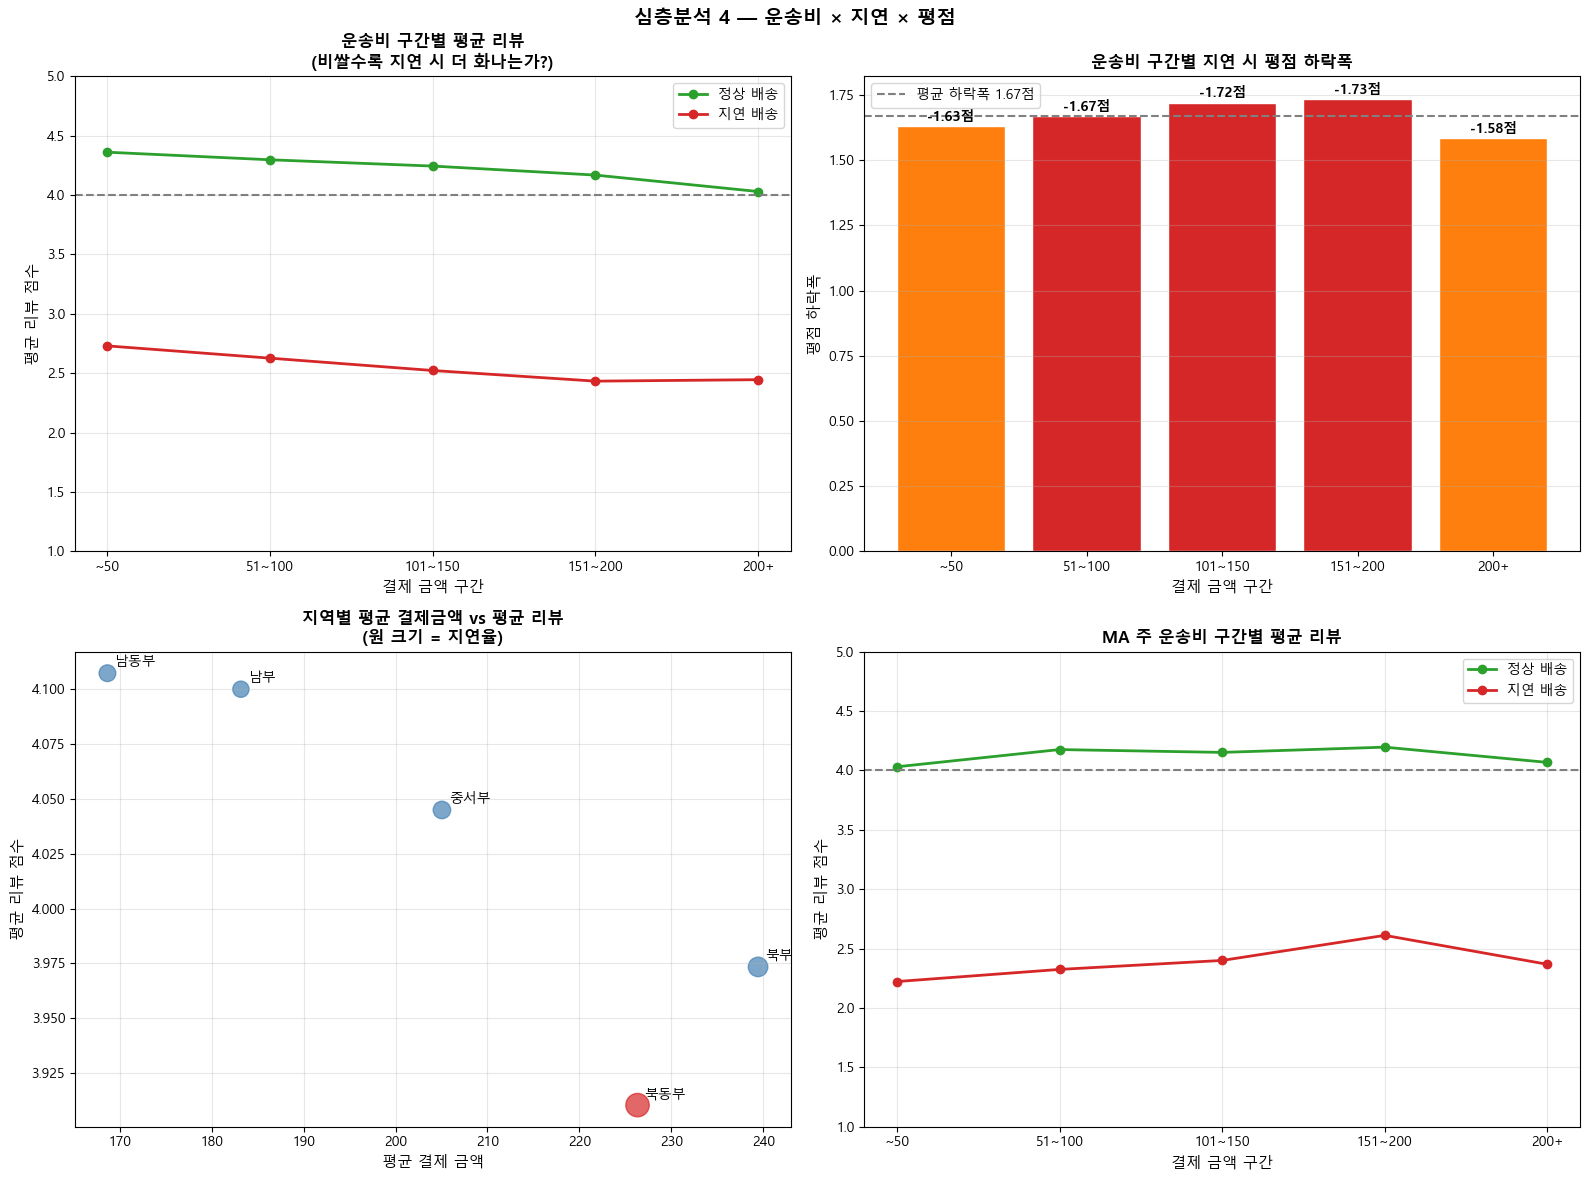

In [15]:
# =============================================
# 심층분석 4 — 운송비 × 지연 × 평점
# 비싼 운송비 냈는데 늦으면 더 화나는가?
# =============================================

df['freight_bucket'] = pd.cut(
    df['payment_value_total'],
    bins=[0, 50, 100, 150, 200, 999],
    labels=['~50', '51~100', '101~150', '151~200', '200+']
)

freight_review = df.groupby(['freight_bucket', 'is_late'])['review_score_mean'].agg(
    ['mean', 'count']
).reset_index()
freight_review.columns = ['freight', 'is_late', 'avg_review', 'count']
freight_review['group'] = freight_review['is_late'].map(
    {False: '정상 배송', True: '지연 배송'}
)

print('=== 운송비 비교 ===')
print(f'MA 평균 결제금액: {df_ma["payment_value_total"].mean():.1f}')
print(f'전체 평균 결제금액: {df["payment_value_total"].mean():.1f}')
print(f'북동부 기타 평균 결제금액: {df_ne_others["payment_value_total"].mean():.1f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 좌상: 운송비 구간별 정상 vs 지연 평점
for group, color in [('정상 배송', '#2ca02c'), ('지연 배송', '#d62728')]:
    sub = freight_review[freight_review['group'] == group].dropna()
    axes[0][0].plot(sub['freight'], sub['avg_review'],
                   'o-', color=color, lw=2, ms=6, label=group)
axes[0][0].axhline(4.0, color='gray', ls='--', lw=1.5)
axes[0][0].set_title('운송비 구간별 평균 리뷰\n(비쌀수록 지연 시 더 화나는가?)',
                     fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('결제 금액 구간', fontsize=11)
axes[0][0].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[0][0].legend(fontsize=10)
axes[0][0].grid(alpha=0.3)
axes[0][0].set_ylim(1, 5)

# 우상: 운송비 구간별 지연 시 평점 하락폭
pivot = freight_review.pivot(index='freight', columns='group', values='avg_review').dropna()
pivot['하락폭'] = pivot['정상 배송'] - pivot['지연 배송']
colors = ['#d62728' if x > pivot['하락폭'].mean() else '#ff7f0e'
          for x in pivot['하락폭']]
bars = axes[0][1].bar(pivot.index, pivot['하락폭'],
                      color=colors, edgecolor='white')
axes[0][1].axhline(pivot['하락폭'].mean(), color='gray', ls='--', lw=1.5,
                   label=f'평균 하락폭 {pivot["하락폭"].mean():.2f}점')
for bar, val in zip(bars, pivot['하락폭']):
    axes[0][1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                   f'-{val:.2f}점', ha='center', fontsize=10, fontweight='bold')
axes[0][1].set_title('운송비 구간별 지연 시 평점 하락폭',
                     fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('결제 금액 구간', fontsize=11)
axes[0][1].set_ylabel('평점 하락폭', fontsize=11)
axes[0][1].legend(fontsize=10)
axes[0][1].grid(axis='y', alpha=0.3)

# 좌하: 지역별 평균 결제금액 vs 평균 리뷰
region_freight = df.groupby('customer_region').agg(
    avg_freight=('payment_value_total', 'mean'),
    avg_review=('review_score_mean', 'mean'),
    late_rate=('is_late', lambda x: x.dropna().mean())
).reset_index()

sizes = (region_freight['late_rate'].fillna(0) * 2000).astype(float)
colors_scatter = ['#d62728' if r == '북동부' else 'steelblue'
                  for r in region_freight['customer_region']]
axes[1][0].scatter(region_freight['avg_freight'], region_freight['avg_review'],
                   s=sizes, alpha=0.7, c=colors_scatter)
for _, row in region_freight.iterrows():
    axes[1][0].annotate(row['customer_region'],
                       (row['avg_freight'], row['avg_review']),
                       textcoords='offset points', xytext=(5, 5), fontsize=10)
axes[1][0].set_title('지역별 평균 결제금액 vs 평균 리뷰\n(원 크기 = 지연율)',
                     fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('평균 결제 금액', fontsize=11)
axes[1][0].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1][0].grid(alpha=0.3)

# 우하: MA 운송비 구간별 지연 시 평점
ma_freight = df_ma.groupby(['freight_bucket', 'is_late'])['review_score_mean'].agg(
    ['mean', 'count']
).reset_index()
ma_freight.columns = ['freight', 'is_late', 'avg_review', 'count']
ma_freight['group'] = ma_freight['is_late'].map(
    {False: '정상 배송', True: '지연 배송'}
)
for group, color in [('정상 배송', '#2ca02c'), ('지연 배송', '#d62728')]:
    sub = ma_freight[ma_freight['group'] == group].dropna()
    axes[1][1].plot(sub['freight'], sub['avg_review'],
                   'o-', color=color, lw=2, ms=6, label=group)
axes[1][1].axhline(4.0, color='gray', ls='--', lw=1.5)
axes[1][1].set_title('MA 주 운송비 구간별 평균 리뷰',
                     fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('결제 금액 구간', fontsize=11)
axes[1][1].set_ylabel('평균 리뷰 점수', fontsize=11)
axes[1][1].legend(fontsize=10)
axes[1][1].grid(alpha=0.3)
axes[1][1].set_ylim(1, 5)

plt.suptitle('심층분석 4 — 운송비 × 지연 × 평점',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()